# **Modeling and Evaluation — Cluster Analysis**

## Objectives

* Fit and evaluate a cluster model to group similar AI job profiles.
* Understand the profile for each cluster.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* Cluster Pipeline
* Train Set
* Most important features to define a cluster plot
* Clusters Profile Description
* Cluster Silhouette

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.

* We access the current directory with `os.getcwd()`

In [4]:
import os
current_dir = os.getcwd()
current_dir
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


We want to make the parent of the current directory the new current directory.

* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [ ]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index'

---

# Load Data

In [6]:
import pandas as pd
import numpy as np

df = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv"),
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
], ignore_index=True)

print(df.shape)
df.head(3)

(14701, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems


We drop columns not useful for clustering:

* `salary_usd` — target variable (including it would cause leakage)
* `required_skills` — high-cardinality free-text column (nearly one unique value per row)
* `company_name` — only 16 unique values, adds no generalizable signal

In [7]:
df = df.drop(['salary_usd', 'required_skills', 'company_name'], axis=1)

print(df.shape)
print(df.dtypes)
df.head(3)

(14701, 11)
job_title              object
experience_level       object
employment_type        object
company_location       object
company_size           object
employee_residence     object
remote_ratio            int64
education_required     object
years_experience        int64
industry               object
benefits_score        float64
dtype: object


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


---

# Cluster Pipeline with all data

## Custom Encoder for Ordinal Variables

We create a custom transformer that applies meaningful ordinal mappings, matching the encoding established in the Feature Engineering notebook:

* `experience_level`: EN=0, MI=1, SE=2, EX=3
* `education_required`: Associate=0, Bachelor=1, Master=2, PhD=3
* `company_size`: S=0, M=1, L=2

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin


class OrdinalMappingEncoder(BaseEstimator, TransformerMixin):
    """Encodes ordinal variables using predefined mappings."""

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.mappings.items():
            X[col] = X[col].map(mapping)
        return X

## ML Cluster Pipeline

The pipeline uses encoding that matches the Feature Engineering notebook:

| Variable | Encoding | Rationale |
|---|---|---|
| `experience_level`, `education_required`, `company_size` | Ordinal mapping | These have a natural order |
| `employment_type` | One-hot encoding | Nominal, 4 categories, no natural order |
| `job_title`, `company_location`, `employee_residence`, `industry` | Frequency encoding | Nominal, high cardinality (15–50 categories) |
| `remote_ratio`, `years_experience`, `benefits_score` | No encoding needed | Already numeric |

In [9]:
from sklearn.pipeline import Pipeline

# Encoding
from feature_engine.encoding import CountFrequencyEncoder, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans


def PipelineCluster():
    pipeline_base = Pipeline([
        # Step 1: Encode ordinal variables with meaningful order
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        # Step 2: One-hot encode employment_type (nominal, 4 categories)
        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        # Step 3: Frequency encode high-cardinality nominal variables
        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        # Step 4: Remove correlated features
        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        # Step 5: Scale all features
        ("scaler", StandardScaler()),

        # Step 6: PCA
        ("PCA", PCA(n_components=6, random_state=0)),

        # Step 7: Cluster
        ("model", KMeans(n_clusters=10, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


In [10]:
pipeline_cluster = PipelineCluster()
pipeline_pre = Pipeline(pipeline_cluster.steps[:4])  # up to SmartCorrelatedSelection
pipeline_pre.fit(df)

print("Dropped:", pipeline_pre['SmartCorrelatedSelection'].features_to_drop_)
print("Kept:", pipeline_pre['SmartCorrelatedSelection'].get_feature_names_out())


Dropped: ['experience_level']
Kept: ['job_title', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'benefits_score', 'employment_type_PT', 'employment_type_CT', 'employment_type_FT']


In [11]:
# After ordinal encoding
df_encoded = Pipeline(pipeline_cluster.steps[:3]).fit_transform(df)
print(df_encoded[['experience_level', 'years_experience']].corr(method='spearman'))


                  experience_level  years_experience
experience_level          1.000000          0.971161
years_experience          0.971161          1.000000


## Principal Component Analysis (PCA)

In [12]:
pipeline_cluster = PipelineCluster()

# All steps except PCA and KMeans
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

(14701, 12) 
 <class 'numpy.ndarray'>


Apply PCA separately to the scaled data to determine the optimal number of components

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        11.190                11.190
Component 1                        11.102                22.292
Component 2                         8.930                31.222
Component 3                         8.598                39.820
Component 4                         8.516                48.336
Component 5                         8.460                56.796
Component 6                         8.374                65.170
Component 7                         8.315                73.485
Component 8                         8.134                81.619
Component 9                         8.056                89.675

* The 10 components explain 89.68% of the data 



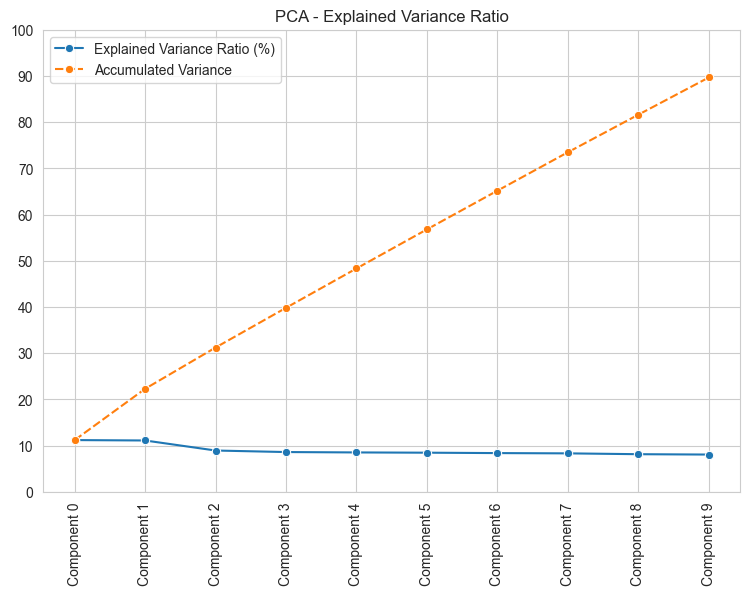

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

n_components = 10


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)
    x_PCA = pca.transform(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = dfExplVarRatio['Explained Variance Ratio (%)'].cumsum()

    PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

    print(dfExplVarRatio)
    print(f"\n* The {n_components} components explain {round(PercentageOfDataExplained, 2)}% of the data \n")

    plt.figure(figsize=(9, 6))
    sns.lineplot(data=dfExplVarRatio, marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.title("PCA - Explained Variance Ratio")
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

Based on the PCA analysis, we select the optimal number of components where the explained variance ratio starts to plateau. Update the `n_components` parameter in `PipelineCluster()` above if needed, then rerun from the next cell.

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        11.190                11.190
Component 1                        11.102                22.292
Component 2                         8.930                31.222
Component 3                         8.598                39.820
Component 4                         8.516                48.336
Component 5                         8.460                56.796
Component 6                         8.374                65.170
Component 7                         8.315                73.485

* The 8 components explain 73.48% of the data 



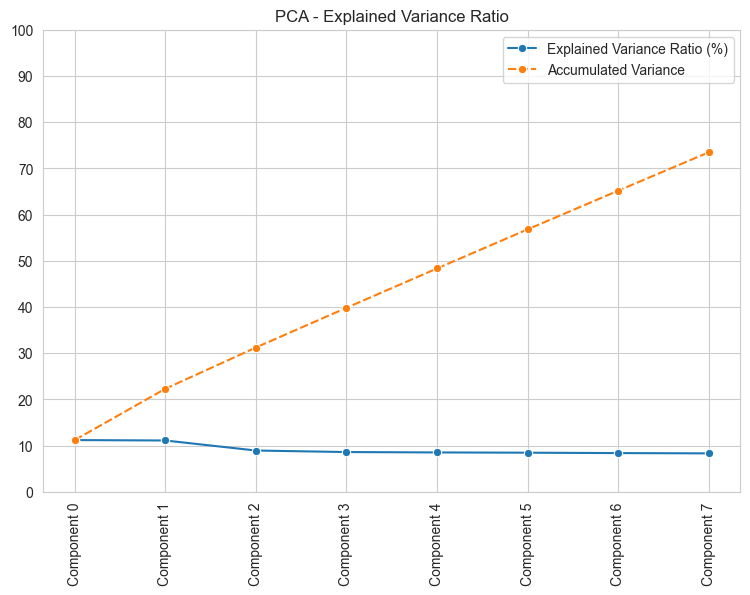

In [14]:
pca_components_analysis(df_pca=df_pca, n_components=8)

Update `PipelineCluster()` with the chosen number of PCA components

In [15]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("PCA", PCA(n_components=8, random_state=0)),

        ("model", KMeans(n_clusters=10, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Elbow Method and Silhouette Score

In [16]:
pipeline_cluster = PipelineCluster()

# Everything except KMeans
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df)

print(df_analysis.shape, '\n', type(df_analysis))

(14701, 8) 
 <class 'numpy.ndarray'>


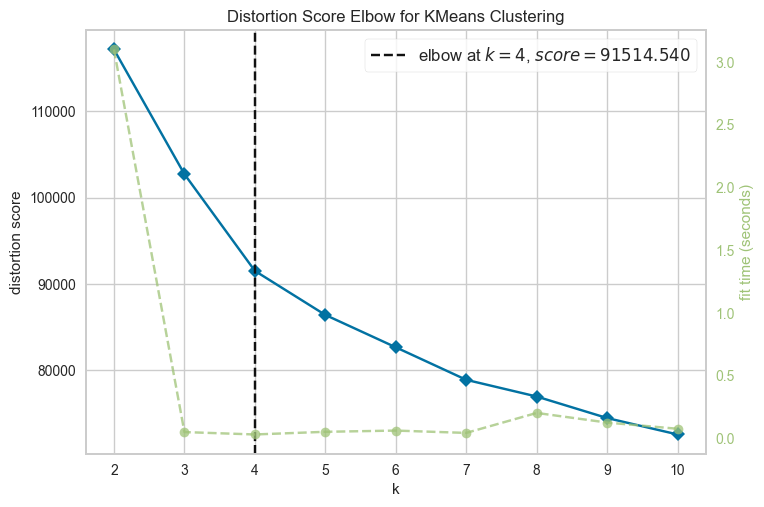

In [17]:
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(KMeans(random_state=0), k=(2, 11), force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()

=== Average Silhouette Score for different number of clusters ===


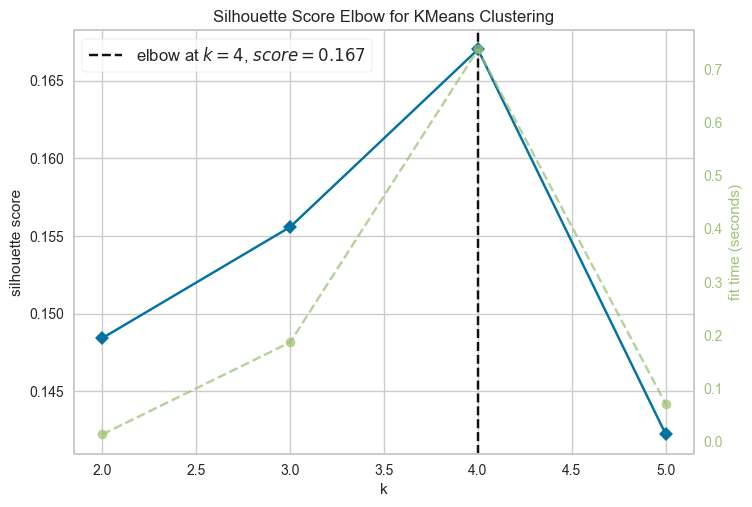



=== Silhouette plot for 2 clusters ===


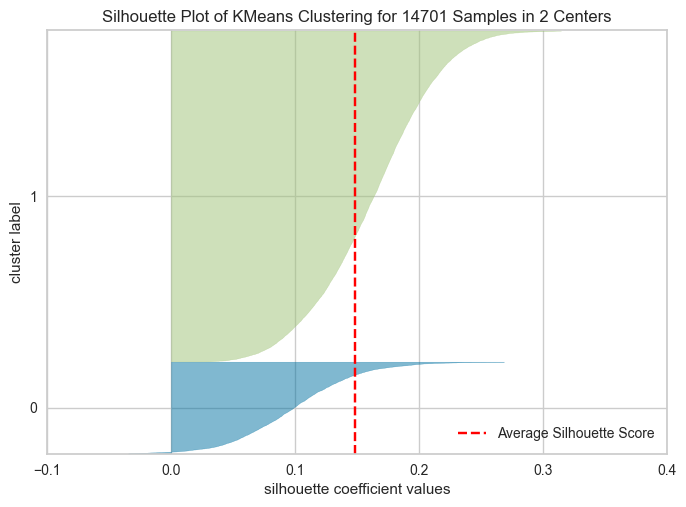



=== Silhouette plot for 3 clusters ===


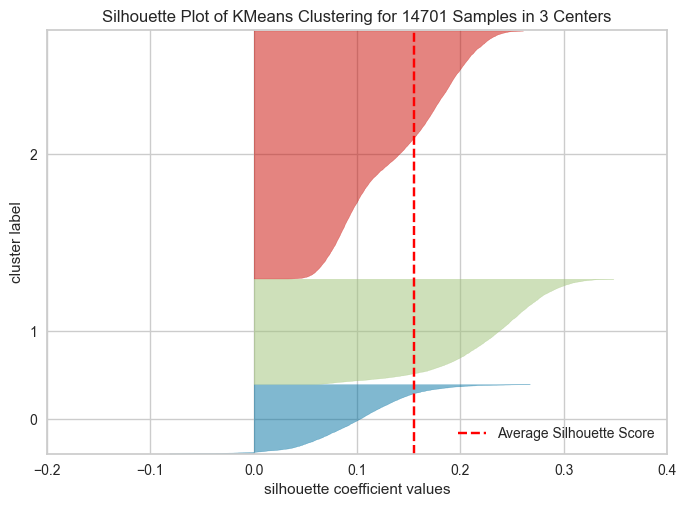



=== Silhouette plot for 4 clusters ===


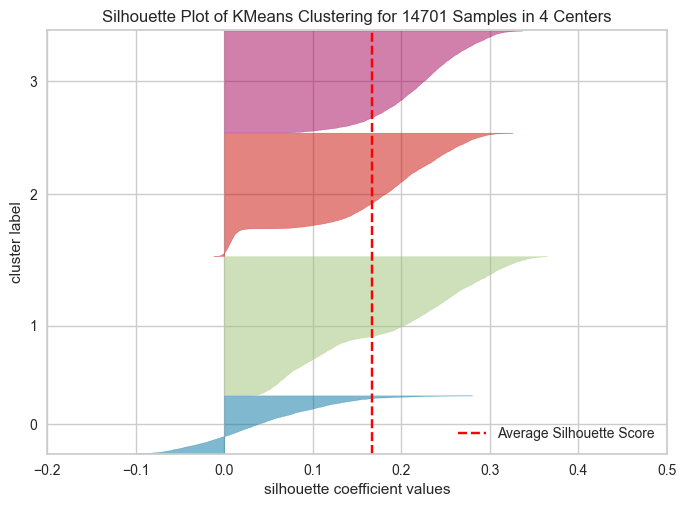



=== Silhouette plot for 5 clusters ===


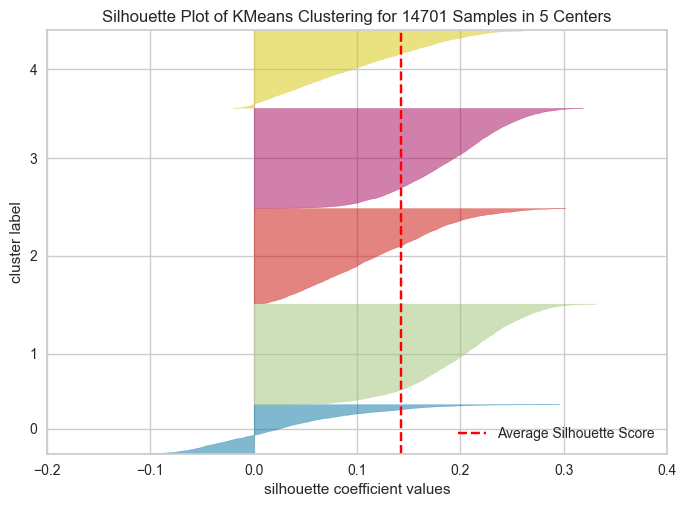

In [18]:
from yellowbrick.cluster import SilhouetteVisualizer

n_cluster_start, n_cluster_stop = 2, 6

print("=== Average Silhouette Score for different number of clusters ===")
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(n_cluster_start, n_cluster_stop),
    metric='silhouette', force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()
print("\n")

for n_clusters in np.arange(start=n_cluster_start, stop=n_cluster_stop):
    print(f"=== Silhouette plot for {n_clusters} clusters ===")
    visualizer = SilhouetteVisualizer(
        KMeans(n_clusters=n_clusters, random_state=0),
        colors='yellowbrick', force_model=True)
    visualizer.fit(df_analysis)
    visualizer.show()
    plt.show()
    print("\n")

In [24]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("PCA", PCA(n_components=8, random_state=0)),

        ("model", KMeans(n_clusters=3, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


Based on the elbow and silhouette analysis, we select the best number of clusters. Update `n_clusters` in `PipelineCluster()` if needed.

## Fit Cluster Pipeline

Quick recap of our data for training the cluster pipeline

In [25]:
X = df.copy()
print(X.shape)
X.head(3)

(14701, 11)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


Fit cluster pipeline

In [26]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [27]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,1
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,2


* Clusters frequencies 
          proportion
Clusters            
2               0.59
1               0.25
0               0.16 




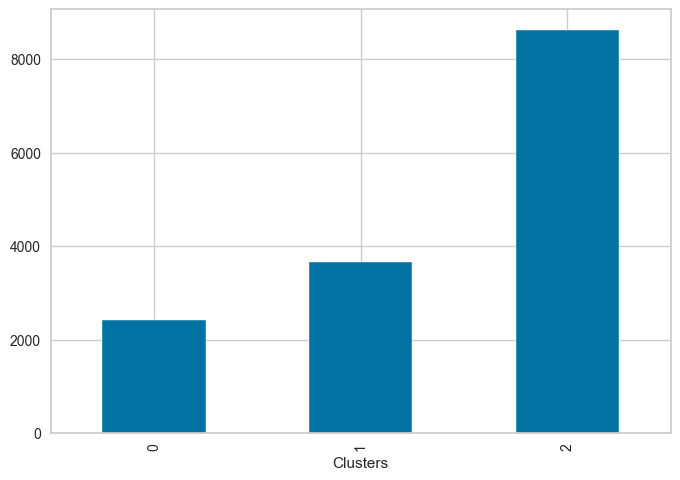

In [28]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

We save the cluster predictions from this pipeline to use for comparison later.

In [29]:
cluster_predictions_with_all_variables = X['Clusters']
cluster_predictions_with_all_variables

0        1
1        1
2        2
3        2
4        2
        ..
14696    2
14697    1
14698    2
14699    2
14700    2
Name: Clusters, Length: 14701, dtype: int32

---

## Fit a classifier to explain clusters

We train a GradientBoostingClassifier where the target is the cluster label and the features are the original variables. This lets us identify which features best define each cluster.

We copy X to a DataFrame `df_clf`

In [30]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,1
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,2


Split Train and Test sets

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

(11760, 11) (2941, 11)


Create classifier pipeline

In [32]:
# ML algorithm
from sklearn.ensemble import GradientBoostingClassifier


def PipelineClf2ExplainClusters():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("model", GradientBoostingClassifier(random_state=0)),
    ])
    return pipeline_base


PipelineClf2ExplainClusters()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


Fit the classifier to the training data

In [33]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Evaluate classifier performance on Train and Test Sets

In [34]:
from sklearn.metrics import classification_report

print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

--- Train Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1915
           1       1.00      1.00      1.00      2931
           2       1.00      1.00      1.00      6914

    accuracy                           1.00     11760
   macro avg       1.00      1.00      1.00     11760
weighted avg       1.00      1.00      1.00     11760

--- Test Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       494
           1       1.00      1.00      1.00       730
           2       1.00      1.00      1.00      1717

    accuracy                           1.00      2941
   macro avg       1.00      1.00      1.00      2941
weighted avg       1.00      1.00      1.00      2941



## Assess the most important features that define a cluster

* Best features to define a cluster: ['job_title', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'benefits_score', 'employment_type_CT', 'employment_type_PT', 'employment_type_FT']


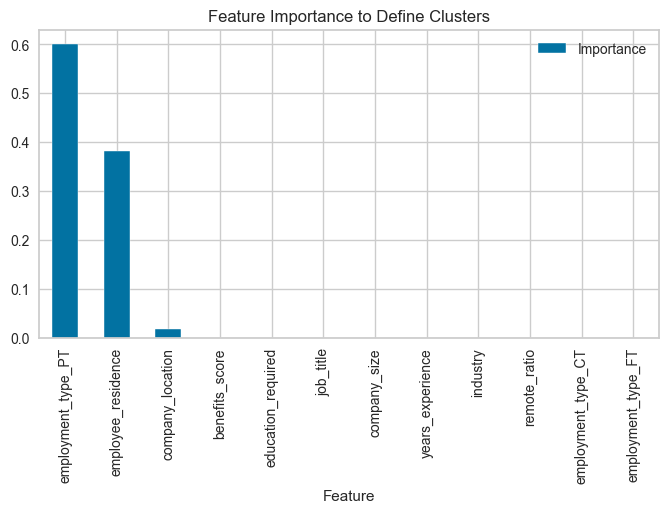

In [35]:
# after data cleaning and feature engineering, the feature space changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 4  # OrdinalMapping, OneHot, Frequency, SmartCorrelated
columns_after_data_cleaning_feat_eng = (
    Pipeline(pipeline_clf_cluster.steps[:data_cleaning_feat_eng_steps])
    .transform(X_train)
    .columns
)

best_features = columns_after_data_cleaning_feat_eng.to_list()

# create DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

print(f"* Best features to define a cluster: {best_features}")
df_feature_importance.plot(kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters")
plt.show()

We will store the `best_features` to use at a later stage.

In [36]:
best_features_pipeline_all_variables = best_features
best_features_pipeline_all_variables

['job_title',
 'company_location',
 'company_size',
 'employee_residence',
 'remote_ratio',
 'education_required',
 'years_experience',
 'industry',
 'benefits_score',
 'employment_type_CT',
 'employment_type_PT',
 'employment_type_FT']

---

# Cluster Analysis

Load function that plots a table with description for all Clusters

In [37]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [DescriptionAllClusters, ClusterDescription], axis=0)

    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points):
    ClusterDescription = pd.DataFrame()

    for column in EDA_ClusterSubset.columns:
        if EDA_ClusterSubset[column].dtype == 'object':
            ClusterDescription[column] = (
                EDA_ClusterSubset[column]
                .value_counts(normalize=True)
                .head(3)
                .apply(lambda x: f"{100*x:.{decimal_points}f}%")
                .reset_index()
                .apply(lambda row: f"'{row.iloc[0]}': {row.iloc[1]} ", axis=1)
                .str.cat(sep=', ')
            )
            ClusterDescription[column] = [ClusterDescription[column].values[0]]
        else:
            ClusterDescription[column] = (
                f"{EDA_ClusterSubset[column].quantile(0.25).round(decimal_points)}"
                f" -- {EDA_ClusterSubset[column].quantile(0.75).round(decimal_points)}"
            )

    ClusterDescription.insert(loc=0, column='Cluster', value=cluster)

    return ClusterDescription

Load a custom function to plot cluster distribution per variable (absolute and relative levels)

In [38]:
import plotly.express as px


def cluster_distribution_per_variable(df, target):
    """
    The data should have 2 variables: the cluster predictions and
    the variable you want to analyse. We use plotly express to create 2 plots:
    Cluster distribution across the target.
    Relative presence of the target level in each cluster.
    """
    df_bar_plot = df.groupby(['Clusters', target]).size().reset_index(name='Count')
    df_bar_plot.columns = ['Clusters', target, 'Count']
    df_bar_plot[target] = df_bar_plot[target].astype('object')

    print(f"\n* Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x='Clusters', y='Count',
                 color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.show()

    df_relative = (
        df
        .groupby(['Clusters', target]).size()
        .unstack(fill_value=0)
        .apply(lambda x: 100 * x / x.sum(), axis=1)
        .stack()
        .reset_index(name='Relative Percentage (%)')
        .sort_values(by=['Clusters', target])
    )
    df_relative.columns = ['Clusters', target, 'Relative Percentage (%)']

    print(f"\n* Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x='Clusters', y='Relative Percentage (%)',
                  color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.update_traces(mode='markers+lines')
    fig.show()

Create a DataFrame that contains best features and Clusters Predictions since we want to analyse the patterns for each cluster.

In [39]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
print(df_cluster_profile.shape)
df_cluster_profile.head(3)

(14701, 10)


,job_title,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,1
2,Research Scientist,Singapore,S,Singapore,100,Associate,6,Energy,7.9,2


We also want to analyse **SalaryBand** levels (Low / Mid / High) derived from `salary_usd`.

In [40]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

,SalaryBand
0,High
1,High
2,Mid


## Cluster profile based on the best features

In [41]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

IndexError: index 0 is out of bounds for axis 0 with size 0

## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [ ]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')

---

# Fit New Cluster Pipeline with most important features

In order to reduce the feature space, we will study the trade-off between the previous Cluster Pipeline (fitted with all variables) and a Pipeline using only the variables that are most important to define the clusters.

To evaluate this trade-off we will:

1. Conduct an elbow method and silhouette analysis and check if the same number of clusters is suggested.
2. Fit a new cluster pipeline and compare if the predictions from this pipeline are "equivalent" to the predictions from the previous pipeline.
3. Fit a classifier to explain clusters, and check if performance on Train and Test sets is similar to the previous pipeline.
4. Check if the most important features and cluster profiles are similar.

In [ ]:
best_features_pipeline_all_variables

## Subset data with the most relevant variables

In [ ]:
df_reduced = df.filter(best_features_pipeline_all_variables)
df_reduced.head(3)

Detect which best features are categorical vs numerical, so we can build the reduced pipeline correctly.

In [ ]:
# Ordinal best features (those with known order)
ordinal_vars_map = {
    'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
    'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
    'company_size': {'S': 0, 'M': 1, 'L': 2},
}

ordinal_best_feats = {k: v for k, v in ordinal_vars_map.items()
                      if k in best_features_pipeline_all_variables}

# One-hot best features
onehot_best_feats = [f for f in ['employment_type']
                     if f in best_features_pipeline_all_variables]

# Frequency-encoded best features
freq_best_feats = [f for f in ['job_title', 'company_location', 'industry']
                   if f in best_features_pipeline_all_variables]

print("Ordinal best features:", list(ordinal_best_feats.keys()))
print("One-hot best features:", onehot_best_feats)
print("Frequency best features:", freq_best_feats)

## Rewrite Cluster Pipeline

We update the pipeline, considering only the most important variables. Since we already know which features to use, we don't need SmartCorrelatedSelection or PCA.

In [ ]:
def PipelineCluster():
    steps = []

    if ordinal_best_feats:
        steps.append(("OrdinalMappingEncoder",
                       OrdinalMappingEncoder(mappings=ordinal_best_feats)))

    if onehot_best_feats:
        steps.append(("OneHotEncoder",
                       OneHotEncoder(variables=onehot_best_feats, drop_last=True)))

    if freq_best_feats:
        steps.append(("FrequencyEncoder",
                       CountFrequencyEncoder(encoding_method='frequency',
                                             variables=freq_best_feats)))

    steps.append(("scaler", StandardScaler()))
    steps.append(("model", KMeans(n_clusters=3, random_state=0)))

    return Pipeline(steps)


PipelineCluster()

## Apply Elbow Method and Silhouette analysis

In [ ]:
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df_reduced)

print(df_analysis.shape, '\n', type(df_analysis))

Elbow Analysis

In [ ]:
visualizer = KElbowVisualizer(KMeans(random_state=0), k=(2, 11), force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()

In [ ]:
n_cluster_start, n_cluster_stop = 2, 5

print("=== Average Silhouette Score for different number of clusters ===")
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(n_cluster_start, n_cluster_stop),
    metric='silhouette', force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()
print("\n")

for n_clusters in np.arange(start=n_cluster_start, stop=n_cluster_stop):
    print(f"=== Silhouette plot for {n_clusters} clusters ===")
    visualizer = SilhouetteVisualizer(
        KMeans(n_clusters=n_clusters, random_state=0),
        colors='yellowbrick', force_model=True)
    visualizer.fit(df_analysis)
    visualizer.show()
    plt.show()
    print("\n")

## Fit New Cluster Pipeline

We set X as our training set for the cluster. It is a copy of `df_reduced`.

In [ ]:
X = df_reduced.copy()
print(X.shape)
X.head(3)

Fit cluster pipeline

In [ ]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [ ]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

In [ ]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

## Compare current cluster predictions to previous cluster predictions

We just fitted a new cluster pipeline and want to compare if its predictions are "equivalent" to the previous cluster.

These are the predictions from the previous cluster pipeline — trained with all variables:

In [ ]:
cluster_predictions_with_all_variables

And these are the predictions from the current cluster pipeline (trained with the best features):

In [ ]:
cluster_predictions_with_best_features = X['Clusters']
cluster_predictions_with_best_features

We use a confusion matrix to evaluate if the predictions of both pipelines are "equivalent"

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(
    cluster_predictions_with_all_variables,
    cluster_predictions_with_best_features))

## Fit a classifier to explain the reduced-feature clusters

In [ ]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

Split Train and Test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

Rewrite pipeline to explain clusters

In [ ]:
def PipelineClf2ExplainClusters():
    steps = []

    if ordinal_best_feats:
        steps.append(("OrdinalMappingEncoder",
                       OrdinalMappingEncoder(mappings=ordinal_best_feats)))

    if onehot_best_feats:
        steps.append(("OneHotEncoder",
                       OneHotEncoder(variables=onehot_best_feats, drop_last=True)))

    if freq_best_feats:
        steps.append(("FrequencyEncoder",
                       CountFrequencyEncoder(encoding_method='frequency',
                                             variables=freq_best_feats)))

    steps.append(("scaler", StandardScaler()))
    steps.append(("model", GradientBoostingClassifier(random_state=0)))

    return Pipeline(steps)


PipelineClf2ExplainClusters()

Fit the classifier

In [ ]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

## Evaluate classifier performance on Train and Test Sets

In [ ]:
print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

## Assess Most Important Features

In [ ]:
# since we don't have feature selection step in this pipeline,
# best_features is X_train columns
best_features = X_train.columns.to_list()

# create a DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

best_features = df_feature_importance['Feature'].to_list()

print(f"* Most important features (ordered): {best_features}")
df_feature_importance.plot(kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters (Reduced Pipeline)")
plt.show()

---

# Cluster Analysis (Reduced Pipeline)

Create a DataFrame that contains the best features and Clusters Predictions: we want to analyse the patterns for each cluster.

In [ ]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
df_cluster_profile.head(3)

We also want to analyse SalaryBand levels

In [ ]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

## Cluster profile on most important features

In [ ]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [ ]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')

---

# Which pipeline should I deploy?

## Decision Criteria

To evaluate the trade-off we assessed the following criteria:

1. Conduct an elbow method and silhouette analysis and check if the same number of clusters is suggested.
2. Fit a new cluster pipeline and compare if the predictions from this pipeline are "equivalent" to the predictions from the previous pipeline.
3. Fit a classifier to explain clusters, and check if performance on Train and Test sets is similar to the previous pipeline.
4. Check if the most important features and cluster profiles are similar.

In [ ]:
pipeline_cluster

---

# Push files to Repo

We will generate the following files:

* Cluster Pipeline
* Train Set
* Feature importance plot
* Clusters Description
* Cluster Silhouette

In [ ]:
import joblib
import os

version = 'v1'
file_path = f'outputs/ml_pipeline/cluster_analysis/{version}'

try:
    os.makedirs(name=file_path)
except Exception as e:
    print(e)

## Cluster pipeline

In [ ]:
joblib.dump(value=pipeline_cluster,
            filename=f"{file_path}/cluster_pipeline.pkl")

## Train Set

In [ ]:
print(X.drop(['Clusters'], axis=1).shape)
X.drop(['Clusters'], axis=1).head(3)

In [ ]:
X.drop(['Clusters'], axis=1).to_csv(f"{file_path}/TrainSet.csv", index=False)

## Most important features plot

These are the features that define a cluster

In [ ]:
df_feature_importance.plot(kind='bar', x='Feature', y='Importance',
                           figsize=(8, 4))
plt.title("Features that Define Clusters")
plt.savefig(f"{file_path}/features_define_cluster.png",
            bbox_inches='tight', dpi=150)
plt.show()

## Cluster Profile

In [ ]:
clusters_profile

In [ ]:
clusters_profile.to_csv(f"{file_path}/clusters_profile.csv")

## Cluster silhouette plot

In [ ]:
fig, axes = plt.subplots(figsize=(7, 5))
visualizer = SilhouetteVisualizer(
    pipeline_cluster['model'], colors='yellowbrick', ax=axes, force_model=True)
visualizer.fit(df_analysis)
plt.savefig(f"{file_path}/clusters_silhouette.png",
            bbox_inches='tight', dpi=150)
plt.show()